# Capítulo 12 — Massas de Ar e Frentes: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | gênese de massa de ar polar: esfriamento radiativo | `solve_ivp` |
| 2 | inclinação de uma frente: relação de Margules | NumPy |
| 3 | frontogênese por deformação — previsão numérica em miniatura | NumPy |
| 4 | meteograma de passagem de frente fria | NumPy |

Exercícios numéricos N1–N4 no fim; soluções em `cap12_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

g, Cp, Rd, sigma = 9.8, 1004.0, 287.0, 5.67e-8
Omega, R_T = 7.292e-5, 6.371e6

## Caso 1 — Fabricando uma massa de ar polar continental

Ar ameno estaciona sobre neve ($T_{sfc}$ fria) por vários dias. A camada inferior (espessura $H$) perde calor por radiação IV líquida:
$$\rho\,C_p\,H\,\frac{dT}{dt} = -\varepsilon\,\sigma\,(T^4 - T_{sfc}^4).$$
A não linearidade do $T^4$ faz o esfriamento começar rápido e *saturar* — a massa de ar leva dias para "ficar pronta" (Stull, §12.1).

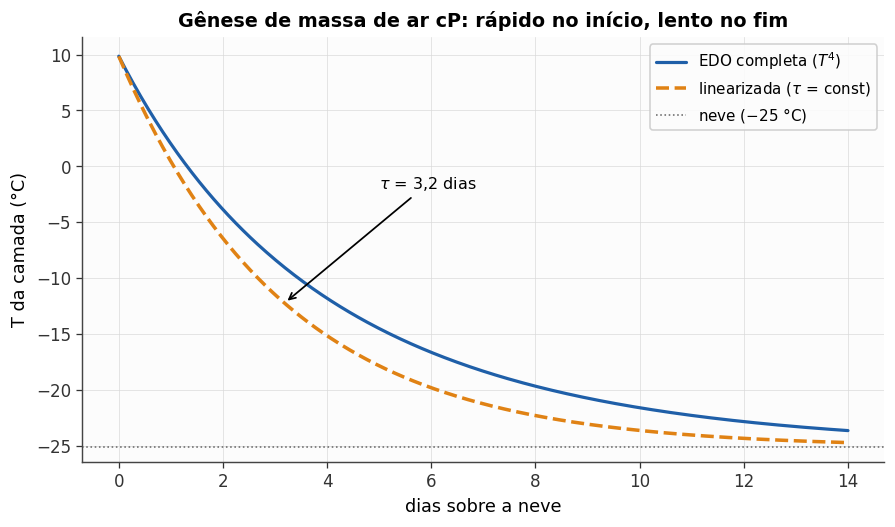

apos 3 dias: -8.3 °C | apos 7 dias: -18.3 °C | apos 14 dias: -23.6 °C


In [2]:
rho, H, eps = 1.2, 1000.0, 0.85
T_sfc = 248.0                       # neve a -25 °C
T0 = 283.0                          # ar de origem marítima: +10 °C

def esfria(t, T):
    return -eps*sigma*(T**4 - T_sfc**4)/(rho*Cp*H)

dias = 14
sol = solve_ivp(esfria, [0, dias*86400], [T0], dense_output=True, rtol=1e-8)
t = np.linspace(0, dias*86400, 400)
T = sol.sol(t)[0]

# escala de tempo linearizada: tau = rho Cp H / (4 eps sigma T^3)
tau = rho*Cp*H/(4*eps*sigma*T0**3)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(t/86400, T - 273.15, color=CORES['azul'], lw=2, label='EDO completa ($T^4$)')
ax.plot(t/86400, T_sfc - 273.15 + (T0 - T_sfc)*np.exp(-t/tau), '--',
        color=CORES['laranja'], label='linearizada ($\\tau$ = const)')
ax.axhline(T_sfc - 273.15, color=CORES['cinza'], ls=':', lw=1, label='neve ($-25$ °C)')
ax.set(xlabel='dias sobre a neve', ylabel='T da camada (°C)',
       title='Gênese de massa de ar cP: rápido no início, lento no fim')
ax.annotate(f'$\\tau$ = {tau/86400:.1f} dias'.replace('.', ','),
            xy=(tau/86400, T0 - 273.15 - 0.63*(T0 - T_sfc)), xytext=(5, -2),
            fontsize=10, arrowprops=dict(arrowstyle='->', lw=1.1))
ax.legend()
plt.show()
print(f'apos 3 dias: {sol.sol(3*86400)[0] - 273.15:+.1f} °C | '
      f'apos 7 dias: {sol.sol(7*86400)[0] - 273.15:+.1f} °C | '
      f'apos 14 dias: {sol.sol(14*86400)[0] - 273.15:+.1f} °C')

## Caso 2 — Que inclinação tem uma frente? A relação de Margules

Duas massas de ar em equilíbrio geostrófico, separadas por uma interface. O balanço entre o contraste de densidade e o salto de vento dá a inclinação:
$$\tan\alpha \;=\; \frac{|f|\,\bar T\,\Delta U_g}{g\,\Delta T}.$$
Frentes reais: inclinações de ~1/50 a 1/300 — cunhas quase deitadas.

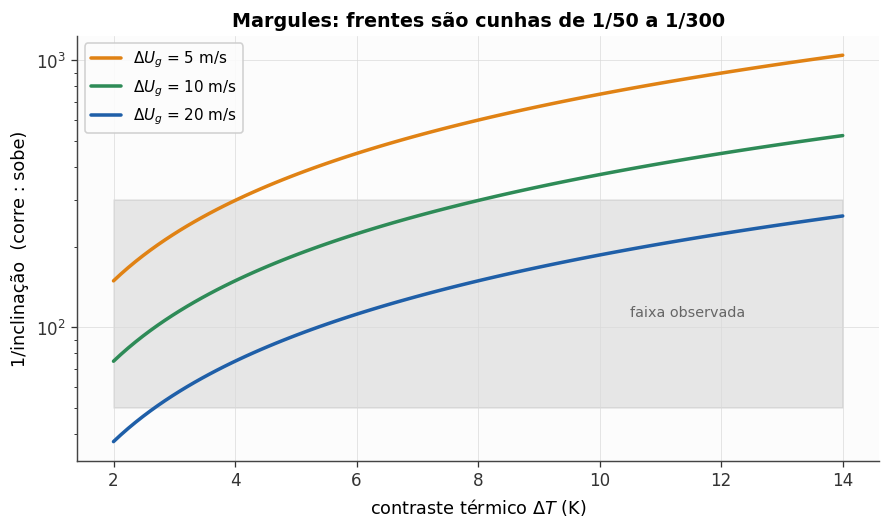

exemplo: dT = 8 K, dU = 10 m/s -> inclinacao 1/299
a 300 km da linha de frente na superficie, a interface esta a 1.0 km de altura


In [3]:
f = 2*Omega*np.sin(np.deg2rad(-40))          # 40°S
T_med = 280.0

dT = np.linspace(2, 14, 100)                  # contraste térmico (K)
fig, ax = plt.subplots(figsize=(9, 4.8))
for dU, cor in [(5, CORES['laranja']), (10, CORES['verde']), (20, CORES['azul'])]:
    incl = np.abs(f)*T_med*dU/(g*dT)          # tan(alpha) ~ alpha
    ax.plot(dT, 1/incl, color=cor, label=f'$\\Delta U_g$ = {dU} m/s')
ax.set(xlabel='contraste térmico $\\Delta T$ (K)', ylabel='1/inclinação  (corre : sobe)',
       yscale='log', title='Margules: frentes são cunhas de 1/50 a 1/300')
ax.fill_between(dT, 50, 300, color=CORES['cinza'], alpha=0.15)
ax.text(10.5, 110, 'faixa observada', fontsize=9, color='#666666')
ax.legend()
plt.show()

dT0, dU0 = 8.0, 10.0
alpha = np.abs(f)*T_med*dU0/(g*dT0)
print(f'exemplo: dT = {dT0:.0f} K, dU = {dU0:.0f} m/s -> inclinacao 1/{1/alpha:.0f}')
print(f'a 300 km da linha de frente na superficie, a interface esta a '
      f'{alpha*300e3/1e3:.1f} km de altura')

## Caso 3 — Frontogênese: a deformação afia o gradiente

Previsão numérica em miniatura (Cap. 20): advectamos $T(x,y)$ num campo de **deformação pura** $u = -ax$, $v = +ay$. O eixo de dilatação ($y$) comprime as isotermas na direção $x$:
$$\frac{d}{dt}\left|\frac{\partial T}{\partial x}\right| = a\,\left|\frac{\partial T}{\partial x}\right| \;\Rightarrow\; |\nabla T| \propto e^{at}.$$
É assim que a circulação de grande escala fabrica frentes em ~1–2 dias.

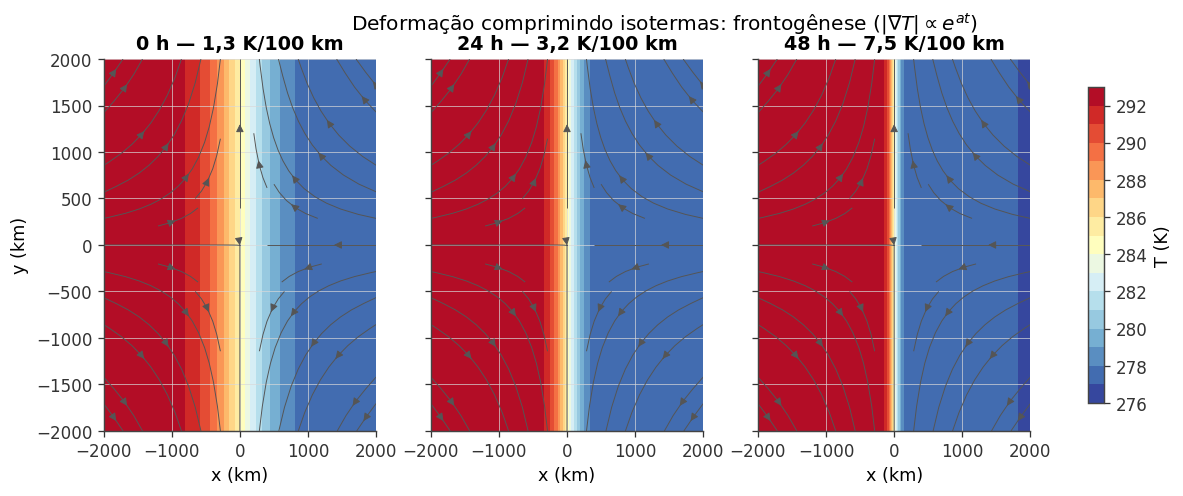

tempo de dobra do gradiente: ln(2)/a = 19.3 h


In [4]:
a = 1e-5                                     # taxa de deformação (1/s)
L = 2000e3
x = np.linspace(-L, L, 200); y = np.linspace(-L, L, 200)
X, Y = np.meshgrid(x, y)

def T_field(t):
    # solução exata da advecção: T conserva-se nas trajetórias x0 = x e^{at}
    return 285.0 - 8.0*np.tanh(X*np.exp(a*t)/6e5)

fig, axs = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for ax, t_h in zip(axs, [0, 24, 48]):
    t = t_h*3600.0
    cf = ax.contourf(X/1e3, Y/1e3, T_field(t), levels=np.arange(276, 294, 1),
                     cmap='RdYlBu_r')
    ax.streamplot(x/1e3, y/1e3, -a*X, a*Y, density=0.5, color='#555555', linewidth=0.6)
    grad = 8.0/6e5*np.exp(a*t)*1e5           # K por 100 km no centro
    ax.set(title=f'{t_h} h — {grad:.1f} K/100 km'.replace('.', ','),
           xlabel='x (km)')
axs[0].set_ylabel('y (km)')
fig.colorbar(cf, ax=axs, label='T (K)', shrink=0.85)
fig.suptitle('Deformação comprimindo isotermas: frontogênese ($|\\nabla T| \\propto e^{at}$)')
plt.show()
print(f'tempo de dobra do gradiente: ln(2)/a = {np.log(2)/a/3600:.1f} h')

## Caso 4 — O meteograma da frente fria

Assinatura clássica na estação (Stull, §12.3): vento de N girando para SW, queda de $T$ e $T_d$, pressão em "V" (mínimo na passagem) e pancadas na linha. Sintetizamos uma passagem para treinar o olho.

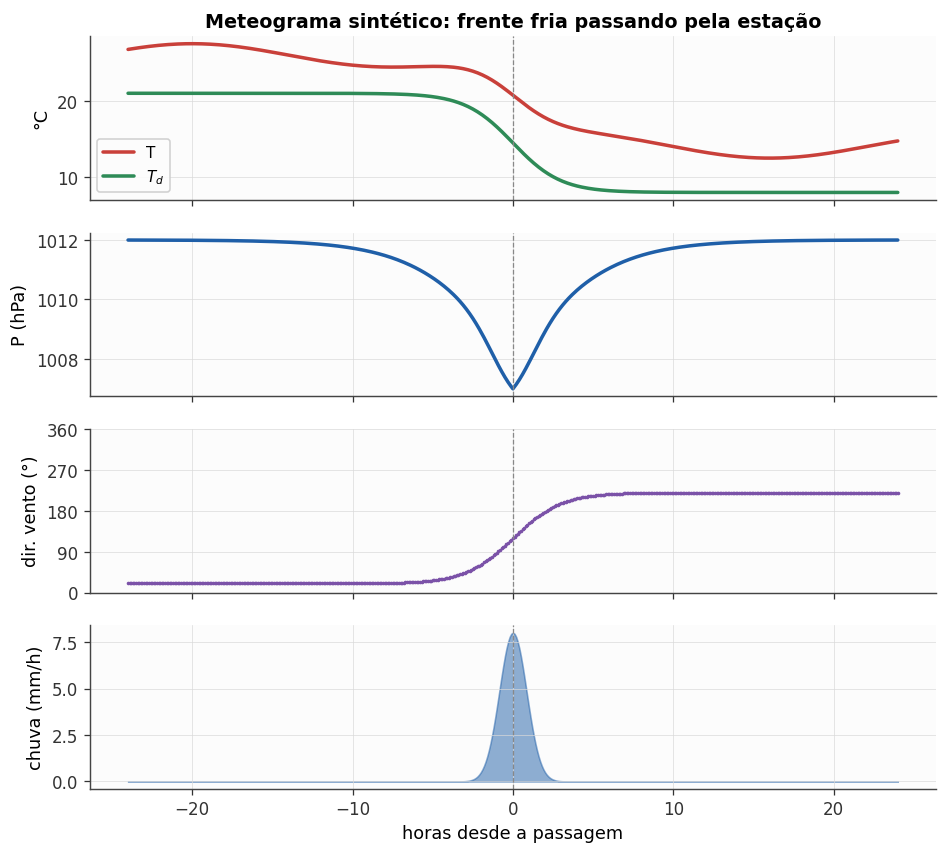

assinaturas: giro de vento N->SW (HS), queda de T e Td, pressao em V,
pancada na linha da frente — compare com o meteograma real mais recente.


In [5]:
t = np.linspace(-24, 24, 481)                # horas em torno da passagem
s = 1/(1 + np.exp(-t/1.5))                   # transição suave
T_s = 26.0 - 12.0*s - 1.5*np.sin(2*np.pi*(t + 14)/24)
Td_s = 21.0 - 13.0*s
P_s = 1008.0 + 4.0*np.abs(np.tanh(t/6)) - 1.0*np.exp(-(t/2)**2)
dir_s = np.mod(360.0 + 20.0 + 200.0*s, 360)  # N (~20°) -> SW (~220°)
chuva = 8.0*np.exp(-(t/1.2)**2)              # pancada na linha

fig, axs = plt.subplots(4, 1, figsize=(9.5, 8.5), sharex=True)
axs[0].plot(t, T_s, color=CORES['vermelho'], label='T')
axs[0].plot(t, Td_s, color=CORES['verde'], label='$T_d$')
axs[0].set_ylabel('°C'); axs[0].legend(loc='lower left')
axs[1].plot(t, P_s, color=CORES['azul'])
axs[1].set_ylabel('P (hPa)')
axs[2].plot(t, dir_s, '.', ms=2.5, color=CORES['roxo'] if 'roxo' in CORES else '#7b4fa6')
axs[2].set_ylabel('dir. vento (°)'); axs[2].set_yticks([0, 90, 180, 270, 360])
axs[3].fill_between(t, chuva, color=CORES['azul'], alpha=0.5)
axs[3].set_ylabel('chuva (mm/h)'); axs[3].set_xlabel('horas desde a passagem')
for ax in axs:
    ax.axvline(0, color='#888888', lw=0.8, ls='--')
axs[0].set_title('Meteograma sintético: frente fria passando pela estação')
plt.show()
print('assinaturas: giro de vento N->SW (HS), queda de T e Td, pressao em V,')
print('pancada na linha da frente — compare com o meteograma real mais recente.')

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap12_solucoes.ipynb`**.

**N1** — No Caso 1, varra $T_{sfc}$ (de $-40$ a $-10$ °C) e $H$ (500 a 2000 m) e trace o tempo para o ar atingir $-15$ °C; que combinação fabrica uma massa cP em menos de 5 dias?

**N2** — Com a relação de Margules, calcule a inclinação para os saltos observados numa frente fria clássica ($\Delta T = 10$ K, $\Delta U_g = 15$ m/s em 45°S) e desenhe o corte vertical da cunha até 500 km da linha de superfície.

**N3** — Acrescente rotação ao Caso 3 ($u = -ax - \omega y$, $v = ay + \omega x$) e compare a taxa de crescimento de $|\nabla T|$ com a deformação pura; a rotação frontogeniza?

**N4** — Construa o meteograma da **frente quente** (giro NE→N lento, subida de T, chuva contínua antes da linha) e compare lado a lado com o da fria do Caso 4.

In [6]:
# N1 — sua solução aqui


In [7]:
# N2 — sua solução aqui


In [8]:
# N3 — sua solução aqui


In [9]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*